# EDA — ADR (Average Daily Rate)

Phân tích ADR theo thời gian lưu trú: tháng (`arrival_date_month`) và ngày trong tuần (`day_of_week`).

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
MONTH_MAP = {name: idx + 1 for idx, name in enumerate(MONTH_ORDER)}

DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]

    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file(min_version: int = 4) -> Path:
    candidates: list[tuple[int, Path]] = []

    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            name = file_path.name
            if "test" in name.lower():
                continue
            match = VERSION_PATTERN.match(name)
            if match:
                version = int(match.group(1))
                if version >= min_version:
                    candidates.append((version, file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(
            f"Không tìm thấy file '{DATA_BASENAME}_v{min_version}+.csv' (loại trừ *test*)."
        )

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


def add_day_of_week(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    arrival_date = pd.to_datetime(
        {
            "year": df["arrival_date_year"],
            "month": df["arrival_date_month"].map(MONTH_MAP),
            "day": df["arrival_date_day_of_month"],
        },
        errors="coerce",
    )
    invalid_dates = arrival_date.isna().sum()
    if invalid_dates:
        print(f"Cảnh báo: {invalid_dates:,} dòng có ngày đến không hợp lệ.")

    df["day_of_week"] = arrival_date.dt.day_name()
    return df


def export_v5_if_needed(df: pd.DataFrame, source_path: Path) -> Path:
    if "day_of_week" in df.columns and source_path.name == "hotel_bookings_v5.csv":
        print("File v5 đã có cột day_of_week.")
        return source_path

    df_v5 = add_day_of_week(df)
    output_path = source_path.parent / f"{DATA_BASENAME}_v5.csv"
    df_v5.to_csv(output_path, index=False)
    print(f"Đã xuất file v5: {output_path.name} ({len(df_v5):,} dòng, {df_v5.shape[1]} cột)")
    return output_path


csv_path = find_latest_versioned_data_file(min_version=4)
print(f"Đang đọc: {csv_path}")
df_raw = pd.read_csv(csv_path)
print(f"Số booking: {len(df_raw):,}")

csv_path = export_v5_if_needed(df_raw, csv_path)
if csv_path.name == "hotel_bookings_v5.csv":
    df_raw = pd.read_csv(csv_path)

# Chỉ phân tích booking không hủy và ADR > 0
df = df_raw[(df_raw["is_canceled"] == 0) & (df_raw["adr"] > 0)].copy()
df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"], categories=MONTH_ORDER, ordered=True
)
if "day_of_week" in df.columns:
    df["day_of_week"] = pd.Categorical(
        df["day_of_week"], categories=DAY_ORDER, ordered=True
    )

print(f"Số booking dùng phân tích ADR (không hủy, adr > 0): {len(df):,}")
print(f"Cột day_of_week: {'có' if 'day_of_week' in df.columns else 'không'}")

Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv


Số booking: 82,811
File v5 đã có cột day_of_week.


Số booking dùng phân tích ADR (không hủy, adr > 0): 58,066
Cột day_of_week: có


## Phân tích theo `arrival_date_month`

- **Box plot**: median, IQR và outlier ADR theo từng tháng
- **Line chart**: ADR trung bình theo tháng ± 1 std (seasonality cho pricing)
- **Heatmap**: ADR trung bình theo tháng × năm (xu hướng year-over-year)

=== Median & IQR ADR theo tháng ===
                    median      q1      q3
arrival_date_month                        
January              68.00   48.00   88.00
February             74.80   54.00   91.00
March                77.35   60.00   97.20
April                98.00   75.60  122.00
May                 108.00   80.00  135.15
June                116.00   92.04  141.00
July                130.00  101.68  164.00
August              140.00  106.66  189.00
September           110.00   85.00  141.51
October              86.95   63.84  114.00
November             70.00   48.50   90.00
December             75.00   55.00   97.40


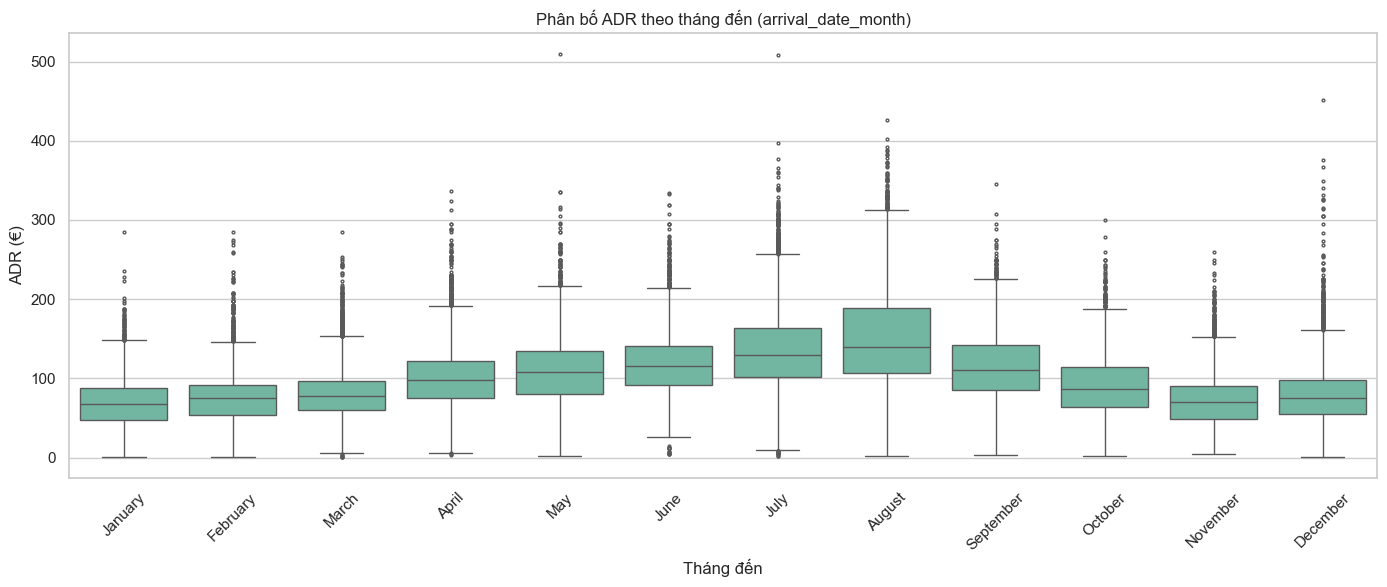

In [2]:
# Box plot ADR theo tháng (thứ tự Jan–Dec)
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="arrival_date_month",
    y="adr",
    order=MONTH_ORDER,
    ax=ax,
    fliersize=2,
    linewidth=1,
)

ax.set_title("Phân bố ADR theo tháng đến (arrival_date_month)")
ax.set_xlabel("Tháng đến")
ax.set_ylabel("ADR (€)")
ax.tick_params(axis="x", rotation=45)

month_stats = (
    df.groupby("arrival_date_month", observed=True)["adr"]
    .agg(median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(MONTH_ORDER)
)
print("=== Median & IQR ADR theo tháng ===")
print(month_stats.round(2))

plt.tight_layout()
plt.show()

Tháng ADR cao nhất: August (151.19 €)
Tháng ADR thấp nhất: January (70.16 €)


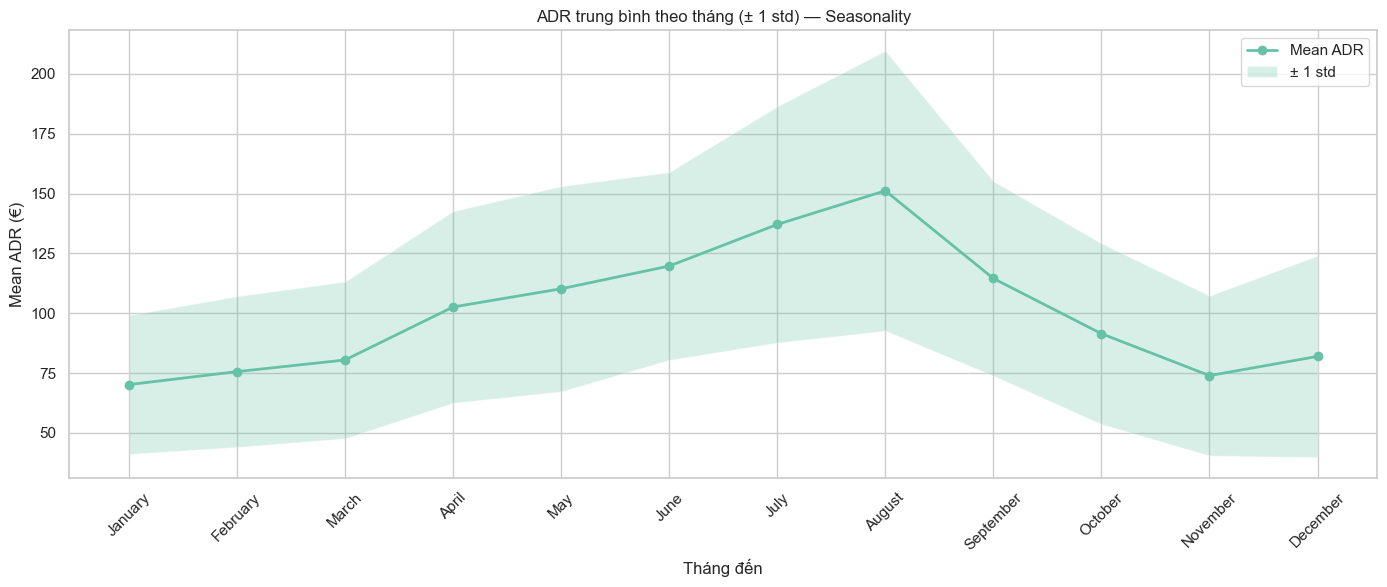

In [3]:
# Line chart: mean(ADR) theo tháng ± 1 std
monthly_adr = (
    df.groupby("arrival_date_month", observed=True)["adr"]
    .agg(mean="mean", std="std", count="count")
    .reindex(MONTH_ORDER)
)

x = np.arange(len(MONTH_ORDER))
mean_adr = monthly_adr["mean"].values
std_adr = monthly_adr["std"].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x, mean_adr, marker="o", linewidth=2, label="Mean ADR")
ax.fill_between(
    x,
    mean_adr - std_adr,
    mean_adr + std_adr,
    alpha=0.25,
    label="± 1 std",
)

ax.set_xticks(x)
ax.set_xticklabels(MONTH_ORDER, rotation=45)
ax.set_title("ADR trung bình theo tháng (± 1 std) — Seasonality")
ax.set_xlabel("Tháng đến")
ax.set_ylabel("Mean ADR (€)")
ax.legend()

peak_month = monthly_adr["mean"].idxmax()
low_month = monthly_adr["mean"].idxmin()
print(f"Tháng ADR cao nhất: {peak_month} ({monthly_adr.loc[peak_month, 'mean']:.2f} €)")
print(f"Tháng ADR thấp nhất: {low_month} ({monthly_adr.loc[low_month, 'mean']:.2f} €)")

plt.tight_layout()
plt.show()

=== Chênh lệch ADR (2017 − 2015) theo tháng ===
arrival_date_month
January        NaN
February       NaN
March          NaN
April          NaN
May            NaN
June           NaN
July         23.82
August       37.79
September      NaN
October        NaN
November       NaN
December       NaN
dtype: float64


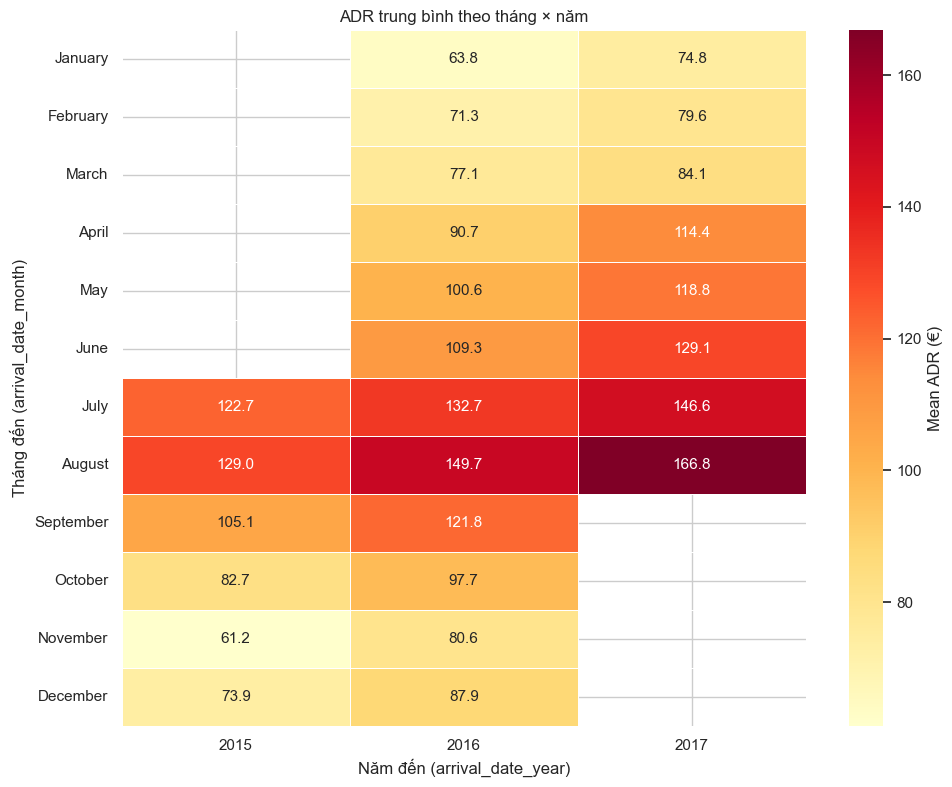

In [4]:
# Heatmap: mean(ADR) theo month × year
heatmap_data = (
    df.groupby(["arrival_date_month", "arrival_date_year"], observed=True)["adr"]
    .mean()
    .unstack("arrival_date_year")
    .reindex(MONTH_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean ADR (€)"},
    ax=ax,
)

ax.set_title("ADR trung bình theo tháng × năm")
ax.set_xlabel("Năm đến (arrival_date_year)")
ax.set_ylabel("Tháng đến (arrival_date_month)")

# YoY growth: so sánh năm cuối vs năm đầu theo từng tháng
years = sorted(df["arrival_date_year"].unique())
if len(years) >= 2:
    yoy = heatmap_data[years[-1]] - heatmap_data[years[0]]
    print(f"=== Chênh lệch ADR ({years[-1]} − {years[0]}) theo tháng ===")
    print(yoy.round(2))

plt.tight_layout()
plt.show()

## Phân tích theo `day_of_week`

- **Bar chart**: mean ADR theo ngày (Mon → Sun) — so sánh mức giá trung bình
- **Box plot**: median, IQR và outlier ADR theo ngày — bổ sung độ phân tán mà bar chart không thể hiện

In [5]:
# Kiểm tra cột day_of_week trong file v5
print("=== Phân bố booking theo day_of_week ===")
print(df["day_of_week"].value_counts().reindex(DAY_ORDER))

dow_adr = (
    df.groupby("day_of_week", observed=True)["adr"]
    .agg(mean="mean", median="median", std="std", count="count")
    .reindex(DAY_ORDER)
)
print("\n=== ADR theo day_of_week ===")
print(dow_adr.round(2))

=== Phân bố booking theo day_of_week ===
day_of_week
Monday       9586
Tuesday      7610
Wednesday    7480
Thursday     8492
Friday       8426
Saturday     8460
Sunday       8012
Name: count, dtype: int64

=== ADR theo day_of_week ===
               mean  median    std  count
day_of_week                              
Monday       105.86   97.00  49.38   9586
Tuesday      102.99   95.00  49.57   7610
Wednesday    102.82   94.50  49.25   7480
Thursday     105.68   96.30  50.05   8492
Friday       109.55   99.00  50.52   8426
Saturday     108.07   98.00  51.75   8460
Sunday       105.85   97.01  47.02   8012


Ngày ADR cao nhất: Friday (109.55 €)
Ngày ADR thấp nhất: Wednesday (102.82 €)


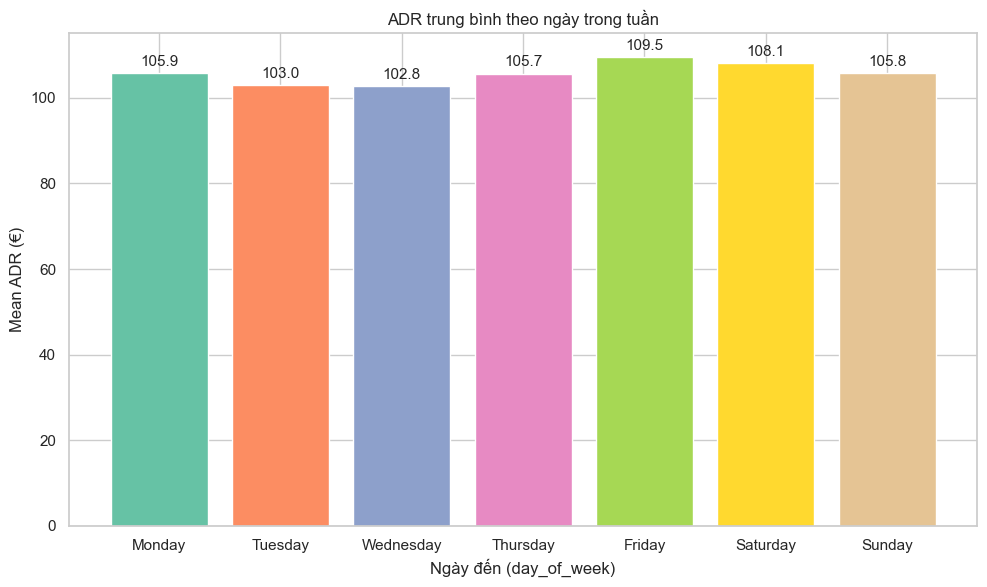

In [6]:
# Bar chart: mean ADR theo day_of_week (Mon → Sun)
dow_adr = (
    df.groupby("day_of_week", observed=True)["adr"]
    .agg(mean="mean", count="count")
    .reindex(DAY_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(DAY_ORDER, dow_adr["mean"], color=sns.color_palette("Set2", len(DAY_ORDER)))

ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_title("ADR trung bình theo ngày trong tuần")
ax.set_xlabel("Ngày đến (day_of_week)")
ax.set_ylabel("Mean ADR (€)")

peak_dow = dow_adr["mean"].idxmax()
low_dow = dow_adr["mean"].idxmin()
print(f"Ngày ADR cao nhất: {peak_dow} ({dow_adr.loc[peak_dow, 'mean']:.2f} €)")
print(f"Ngày ADR thấp nhất: {low_dow} ({dow_adr.loc[low_dow, 'mean']:.2f} €)")

plt.tight_layout()
plt.show()

=== Median & IQR ADR theo day_of_week ===
             median     q1      q3
day_of_week                       
Monday        97.00  72.00  131.00
Tuesday       95.00  68.00  129.00
Wednesday     94.50  68.07  128.00
Thursday      96.30  70.02  132.00
Friday        99.00  75.00  138.00
Saturday      98.00  71.00  136.02
Sunday        97.01  74.80  129.97


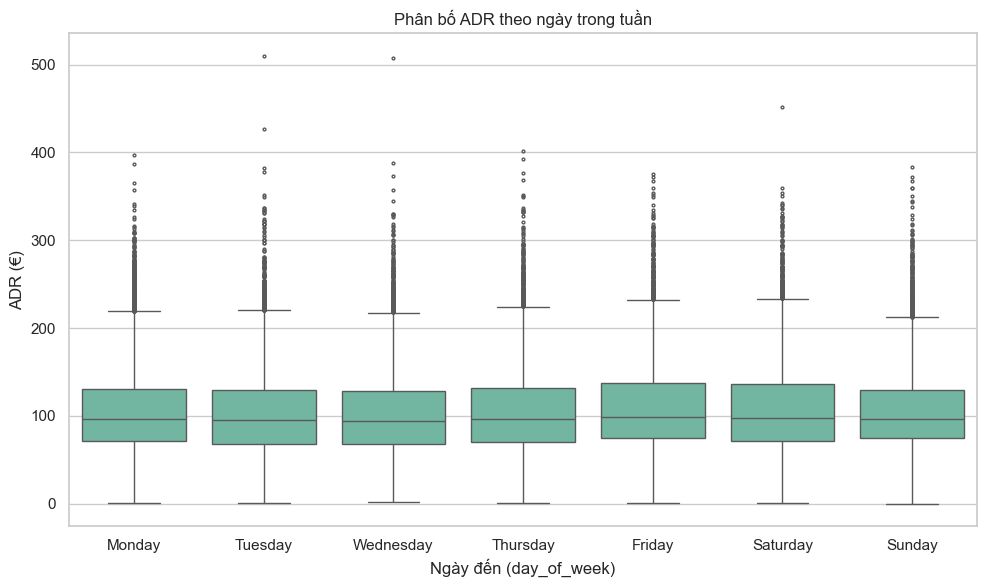

In [7]:
# Box plot ADR theo day_of_week
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="day_of_week",
    y="adr",
    order=DAY_ORDER,
    ax=ax,
    fliersize=2,
    linewidth=1,
)

ax.set_title("Phân bố ADR theo ngày trong tuần")
ax.set_xlabel("Ngày đến (day_of_week)")
ax.set_ylabel("ADR (€)")

dow_stats = (
    df.groupby("day_of_week", observed=True)["adr"]
    .agg(median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(DAY_ORDER)
)
print("=== Median & IQR ADR theo day_of_week ===")
print(dow_stats.round(2))

plt.tight_layout()
plt.show()

## Phân tích theo `room_type`

- **Bar chart ngang**: mean ADR theo `reserved_room_type` (sắp giảm dần)
- **Box plot**: ADR theo `room_match` (reserved vs assigned có khớp không)
- **Heatmap**: mean ADR theo `reserved_room_type` × `hotel`

Loại phòng ADR cao nhất: H (184.67 €)

=== Mean ADR theo reserved_room_type (giảm dần) ===
reserved_room_type
H    184.67
G    180.99
F    165.63
C    158.27
L    144.00
E    123.21
D    119.42
A     93.04
B     91.45
Name: mean, dtype: float64


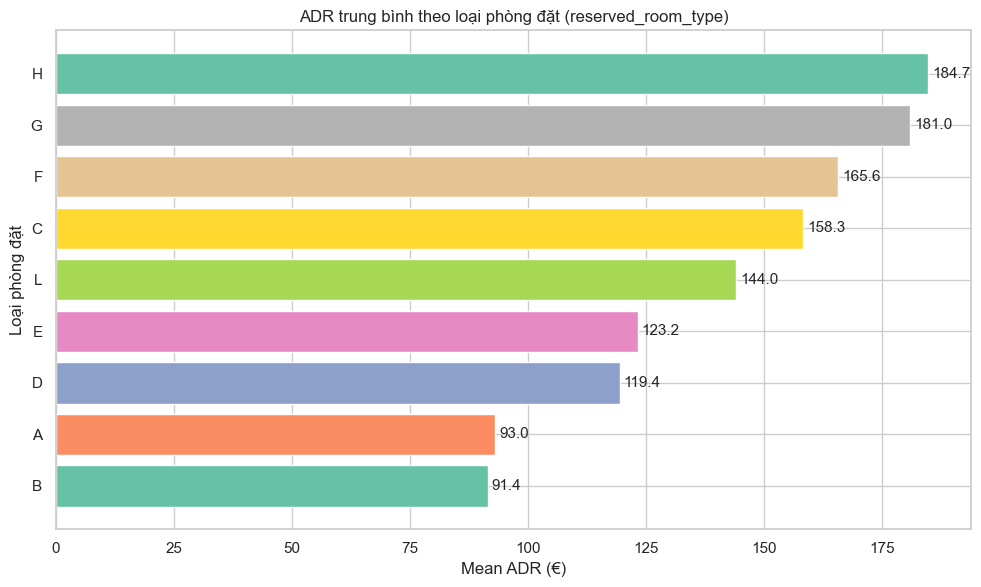

In [8]:
# Bar chart ngang: mean ADR theo reserved_room_type (sắp giảm dần)
room_adr = (
    df.groupby("reserved_room_type", observed=True)["adr"]
    .agg(mean="mean", count="count")
    .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(room_adr.index, room_adr["mean"], color=sns.color_palette("Set2", len(room_adr)))

ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_title("ADR trung bình theo loại phòng đặt (reserved_room_type)")
ax.set_xlabel("Mean ADR (€)")
ax.set_ylabel("Loại phòng đặt")

top_room = room_adr["mean"].idxmax()
print(f"Loại phòng ADR cao nhất: {top_room} ({room_adr.loc[top_room, 'mean']:.2f} €)")
print("\n=== Mean ADR theo reserved_room_type (giảm dần) ===")
print(room_adr["mean"].sort_values(ascending=False).round(2))

plt.tight_layout()
plt.show()

Tỷ lệ khớp phòng: 82.0%

=== ADR theo room_match ===
              mean  median  count
room_match                       
False        90.96   81.95  10424
True        109.20   99.00  47642

Insight: Booking không khớp phòng có mean ADR thấp hơn 18.24 € so với booking khớp phòng.
(Không khớp gồm cả upgrade và downgrade; ADR phản ánh giá đặt ban đầu, không phải loại phòng thực tế nhận.)


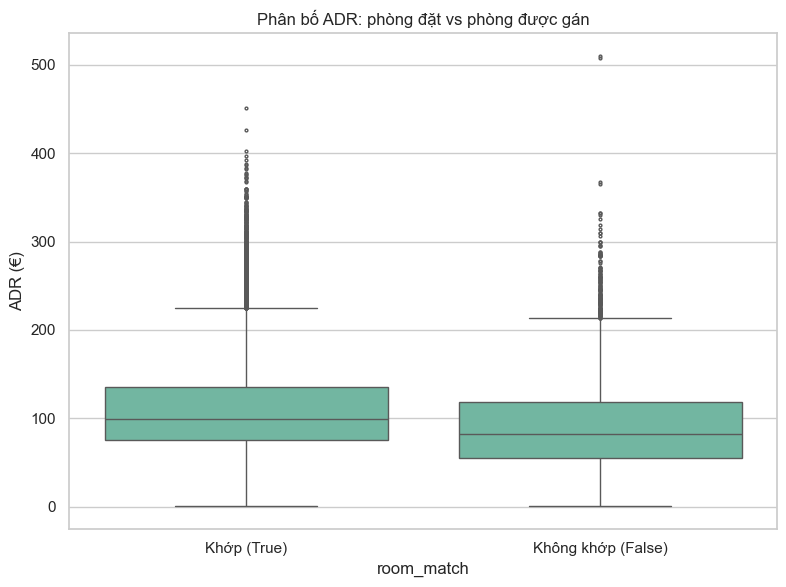

In [9]:
# Box plot ADR theo room_match (reserved == assigned)
df["room_match"] = df["reserved_room_type"] == df["assigned_room_type"]

match_labels = {True: "Khớp (True)", False: "Không khớp (False)"}
df["room_match_label"] = df["room_match"].map(match_labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="room_match_label",
    y="adr",
    order=["Khớp (True)", "Không khớp (False)"],
    ax=ax,
    fliersize=2,
    linewidth=1,
)

ax.set_title("Phân bố ADR: phòng đặt vs phòng được gán")
ax.set_xlabel("room_match")
ax.set_ylabel("ADR (€)")

match_stats = (
    df.groupby("room_match", observed=True)["adr"]
    .agg(mean="mean", median="median", count="count")
)
match_rate = df["room_match"].mean()
print(f"Tỷ lệ khớp phòng: {match_rate:.1%}")
print("\n=== ADR theo room_match ===")
print(match_stats.round(2))

diff = match_stats.loc[False, "mean"] - match_stats.loc[True, "mean"]
print(
    f"\nInsight: Booking không khớp phòng có mean ADR "
    f"{'cao' if diff > 0 else 'thấp'} hơn {abs(diff):.2f} € so với booking khớp phòng."
)
print(
    "(Không khớp gồm cả upgrade và downgrade; ADR phản ánh giá đặt ban đầu, "
    "không phải loại phòng thực tế nhận.)"
)

plt.tight_layout()
plt.show()

=== Mean ADR: reserved_room_type × hotel ===
hotel               City Hotel  Resort Hotel
reserved_room_type                          
H                          NaN        184.67
G                       227.08        165.39
F                       190.34        135.51
C                       101.80        158.76
L                          NaN        144.00
E                       159.46        112.41
D                       130.80        103.30
A                       100.74         78.56
B                        91.38        104.67


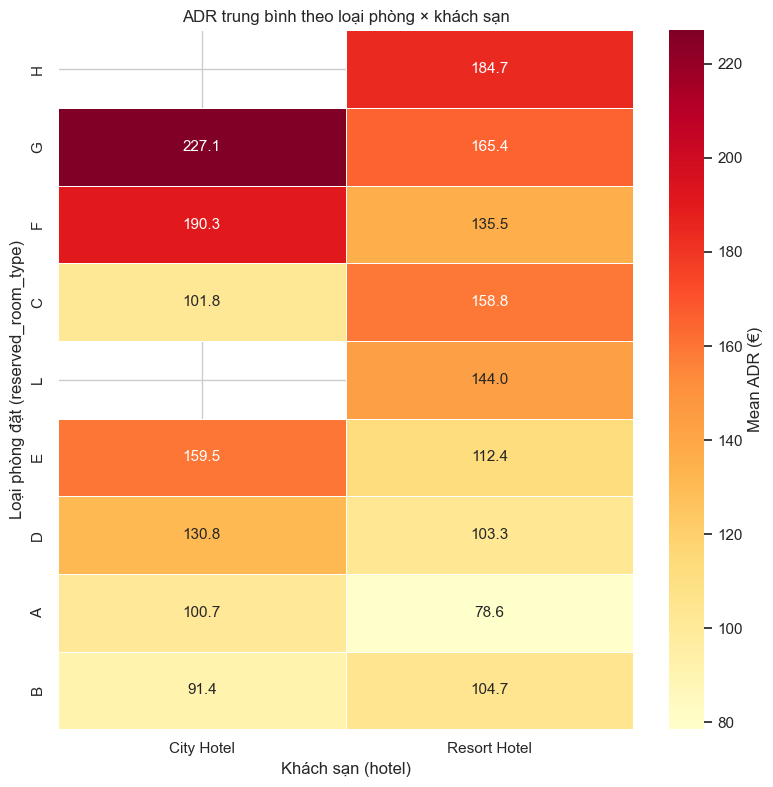

In [10]:
# Heatmap: mean ADR theo reserved_room_type × hotel
room_hotel_adr = (
    df.groupby(["reserved_room_type", "hotel"], observed=True)["adr"]
    .mean()
    .unstack("hotel")
)

row_order = (
    df.groupby("reserved_room_type", observed=True)["adr"]
    .mean()
    .sort_values(ascending=False)
    .index
)
hotel_order = sorted(df["hotel"].unique())
room_hotel_adr = room_hotel_adr.reindex(row_order)[hotel_order]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    room_hotel_adr,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean ADR (€)"},
    ax=ax,
)

ax.set_title("ADR trung bình theo loại phòng × khách sạn")
ax.set_xlabel("Khách sạn (hotel)")
ax.set_ylabel("Loại phòng đặt (reserved_room_type)")

print("=== Mean ADR: reserved_room_type × hotel ===")
print(room_hotel_adr.round(2))

plt.tight_layout()
plt.show()

## Phân tích theo `customer_type`

- **Bar chart**: mean ADR theo segment khách (Transient, Transient-Party, Contract, Group)
- **Box plot**: median, IQR và outlier ADR theo `customer_type`
- **Grouped bar**: mean ADR theo `customer_type` × `hotel` — so sánh Resort vs City Hotel

Segment ADR cao nhất: Transient (108.74 €)

=== Mean ADR theo customer_type ===
customer_type
Transient          108.74
Transient-Party     93.61
Contract            92.81
Group               87.23
Name: mean, dtype: float64


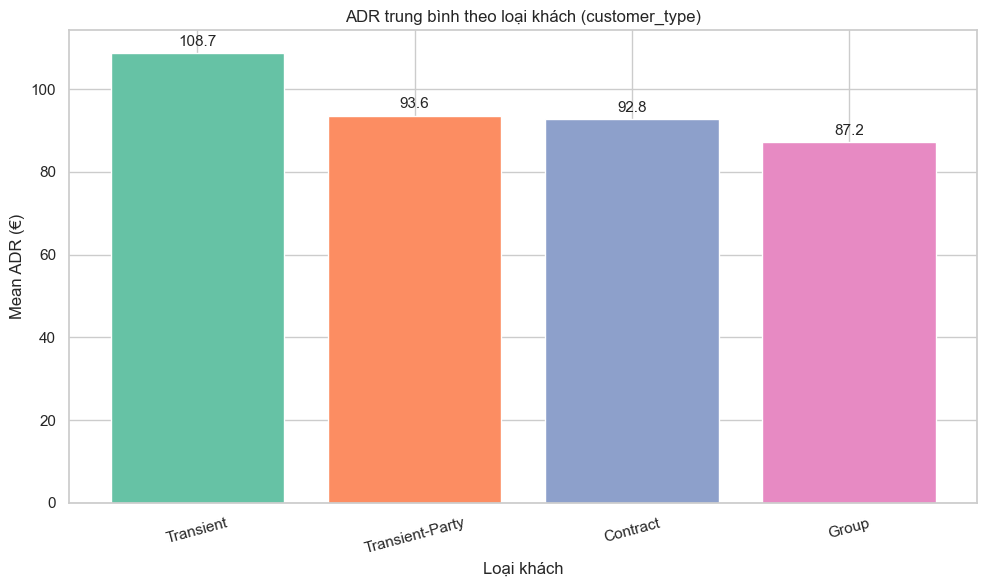

In [11]:
CUSTOMER_TYPE_ORDER = ["Transient", "Transient-Party", "Contract", "Group"]

# Bar chart: mean ADR theo customer_type
customer_adr = (
    df.groupby("customer_type", observed=True)["adr"]
    .agg(mean="mean", count="count")
    .reindex(CUSTOMER_TYPE_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(CUSTOMER_TYPE_ORDER, customer_adr["mean"], color=sns.color_palette("Set2", len(CUSTOMER_TYPE_ORDER)))

ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_title("ADR trung bình theo loại khách (customer_type)")
ax.set_xlabel("Loại khách")
ax.set_ylabel("Mean ADR (€)")
ax.tick_params(axis="x", rotation=15)

top_segment = customer_adr["mean"].idxmax()
print(f"Segment ADR cao nhất: {top_segment} ({customer_adr.loc[top_segment, 'mean']:.2f} €)")
print("\n=== Mean ADR theo customer_type ===")
print(customer_adr["mean"].round(2))

plt.tight_layout()
plt.show()

=== Median & IQR ADR theo customer_type ===
                 median    q1      q3
customer_type                        
Transient         99.00  74.0  136.44
Transient-Party   85.50  65.0  112.67
Contract          90.32  68.0  114.00
Group             76.00  60.0  111.65


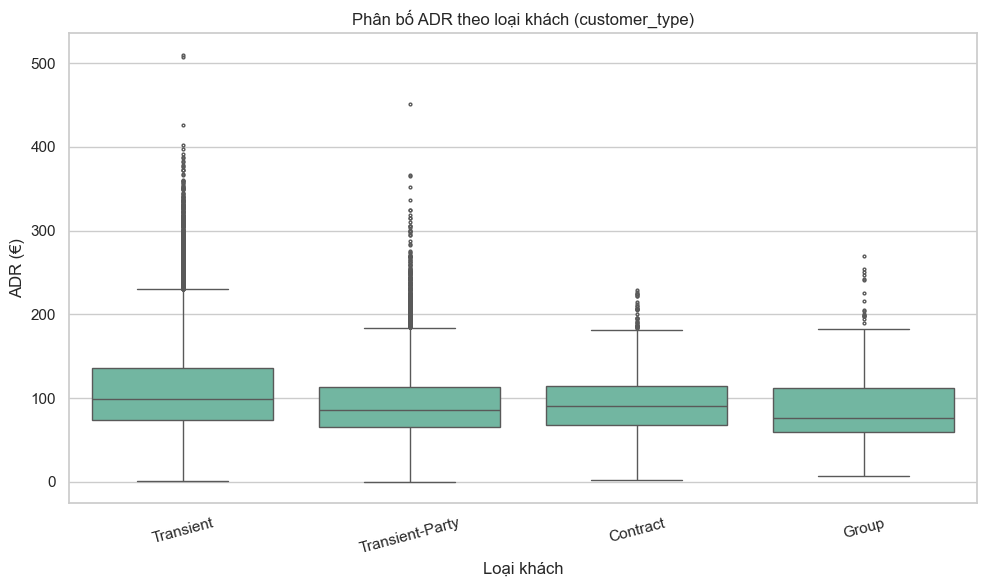

In [12]:
# Box plot ADR theo customer_type
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="customer_type",
    y="adr",
    order=CUSTOMER_TYPE_ORDER,
    ax=ax,
    fliersize=2,
    linewidth=1,
)

ax.set_title("Phân bố ADR theo loại khách (customer_type)")
ax.set_xlabel("Loại khách")
ax.set_ylabel("ADR (€)")
ax.tick_params(axis="x", rotation=15)

customer_stats = (
    df.groupby("customer_type", observed=True)["adr"]
    .agg(median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(CUSTOMER_TYPE_ORDER)
)
print("=== Median & IQR ADR theo customer_type ===")
print(customer_stats.round(2))

plt.tight_layout()
plt.show()

=== Mean ADR: customer_type × hotel ===


hotel            City Hotel  Resort Hotel
customer_type                            
Transient            114.22        100.47
Transient-Party       99.22         85.80
Contract             110.66         79.92
Group                 91.70         82.45
Transient: City − Resort = +13.76 € (City Hotel cao hơn)
Transient-Party: City − Resort = +13.42 € (City Hotel cao hơn)
Contract: City − Resort = +30.74 € (City Hotel cao hơn)
Group: City − Resort = +9.24 € (City Hotel cao hơn)


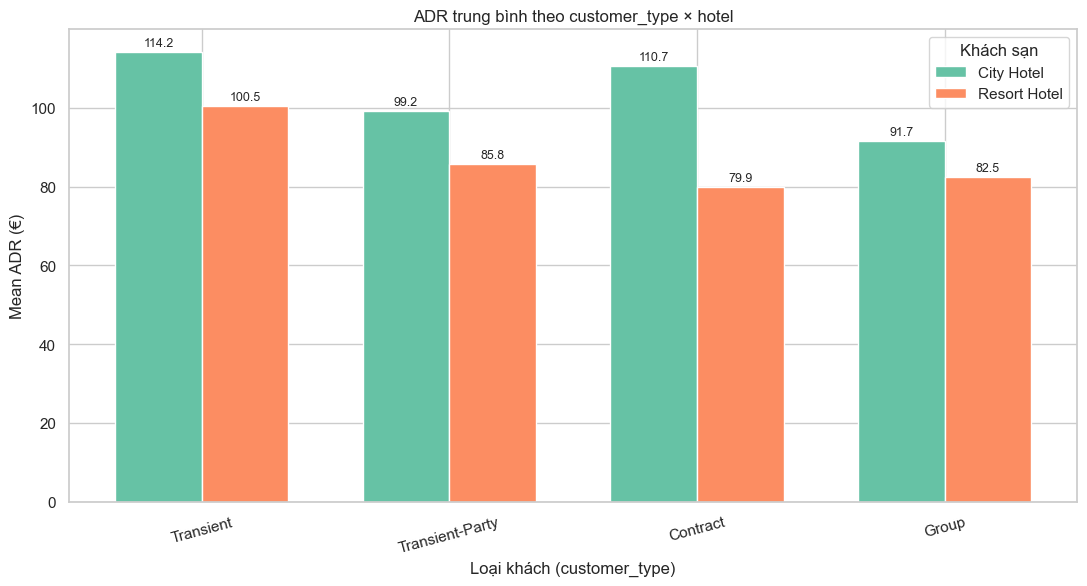

In [13]:
# Grouped bar: mean ADR theo customer_type × hotel
customer_hotel_adr = (
    df.groupby(["customer_type", "hotel"], observed=True)["adr"]
    .mean()
    .unstack("hotel")
    .reindex(CUSTOMER_TYPE_ORDER)
)

hotel_order = sorted(df["hotel"].unique())
x = np.arange(len(CUSTOMER_TYPE_ORDER))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
for i, hotel in enumerate(hotel_order):
    offset = (i - (len(hotel_order) - 1) / 2) * bar_width
    values = customer_hotel_adr[hotel].values
    bars = ax.bar(x + offset, values, bar_width, label=hotel)
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CUSTOMER_TYPE_ORDER, rotation=15)
ax.set_title("ADR trung bình theo customer_type × hotel")
ax.set_xlabel("Loại khách (customer_type)")
ax.set_ylabel("Mean ADR (€)")
ax.legend(title="Khách sạn")

print("=== Mean ADR: customer_type × hotel ===")
print(customer_hotel_adr.round(2))

for ctype in CUSTOMER_TYPE_ORDER:
    city = customer_hotel_adr.loc[ctype, "City Hotel"]
    resort = customer_hotel_adr.loc[ctype, "Resort Hotel"]
    diff = city - resort
    higher = "City Hotel" if diff > 0 else "Resort Hotel"
    print(f"{ctype}: City − Resort = {diff:+.2f} € ({higher} cao hơn)")

plt.tight_layout()
plt.show()